In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv('HousingData.csv')

# 2. Inspect shape & missing values
print("Dataset Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())

# 3. Impute numerical columns with their median
numerical_missing = ['CRIM', 'ZN', 'INDUS', 'AGE', 'LSTAT']
for col in numerical_missing:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical/binary column CHAS with its mode
df['CHAS'] = df['CHAS'].fillna(df['CHAS'].mode()[0])

# Verify all missing values are resolved
print("Remaining nulls:", df.isnull().sum().sum())

Dataset Shape: (506, 14)

Missing values per column:
 CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64
Remaining nulls: 0


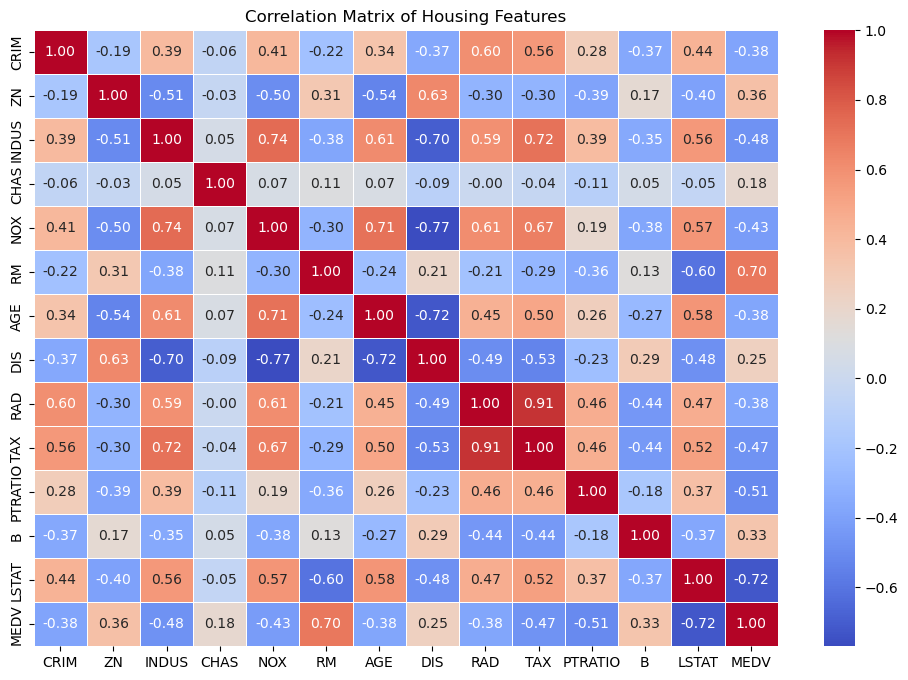

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Housing Features")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop(columns=['MEDV'])
y = df['MEDV']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features for linear/regularized models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": (LinearRegression(), True),
    "Ridge Regression": (Ridge(alpha=1.0), True),
    "Lasso Regression": (Lasso(alpha=0.1), True),
    "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42), False),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=42), False)
}

performance = []

for name, (model, use_scaled) in models.items():
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    
    # Train
    model.fit(X_tr, y_train)
    
    # Predict
    preds = model.predict(X_te)
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    performance.append({
        "Model": name,
        "MAE ($1000s)": round(mae, 3),
        "RMSE ($1000s)": round(rmse, 3),
        "R2 Score": round(r2, 4)
    })

# Display comparative results
results_df = pd.DataFrame(performance).sort_values(by="R2 Score", ascending=False)
print(results_df)

               Model  MAE ($1000s)  RMSE ($1000s)  R2 Score
4  Gradient Boosting         1.922          2.706    0.9002
3      Random Forest         2.064          2.867    0.8879
0  Linear Regression         3.149          5.000    0.6591
1   Ridge Regression         3.146          5.000    0.6591
2   Lasso Regression         3.211          5.109    0.6440


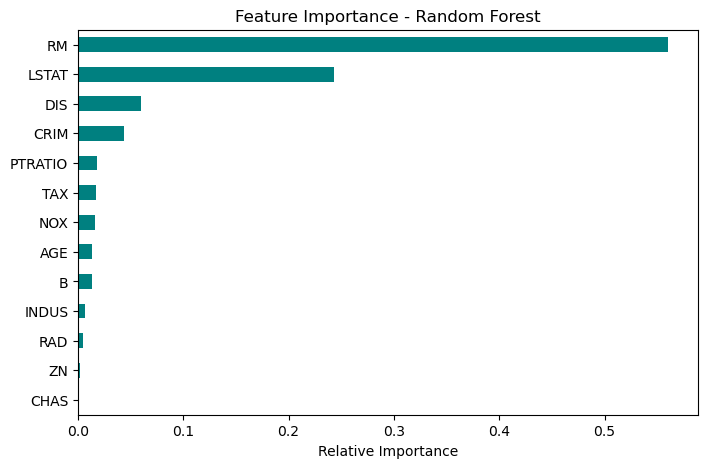

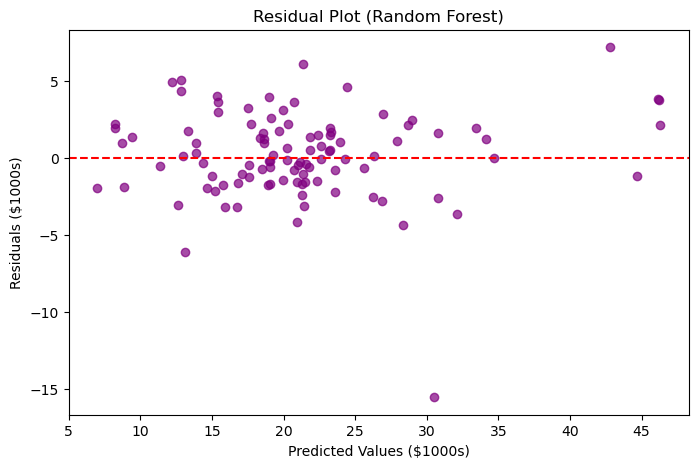

In [13]:
# 1. Feature Importance (Random Forest)
rf_model = models["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Relative Importance")
plt.show()

# 2. Residual Analysis
rf_preds = rf_model.predict(X_test)
residuals = y_test - rf_preds

plt.figure(figsize=(8, 5))
plt.scatter(rf_preds, residuals, alpha=0.7, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values ($1000s)")
plt.ylabel("Residuals ($1000s)")
plt.title("Residual Plot (Random Forest)")
plt.show()